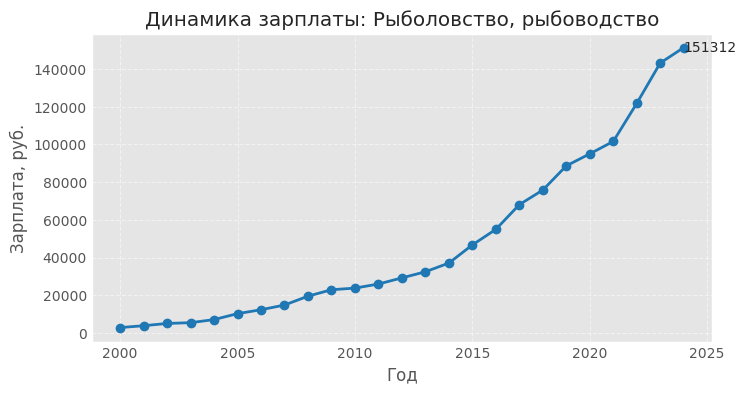

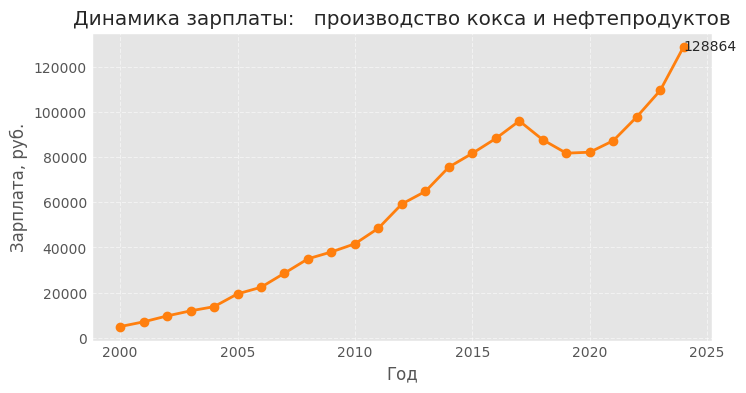

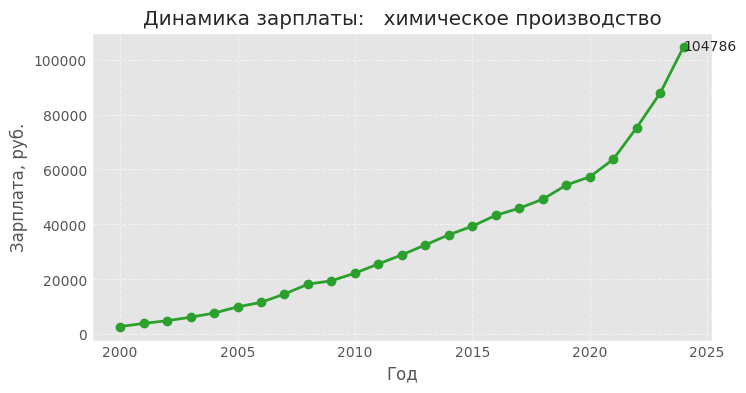

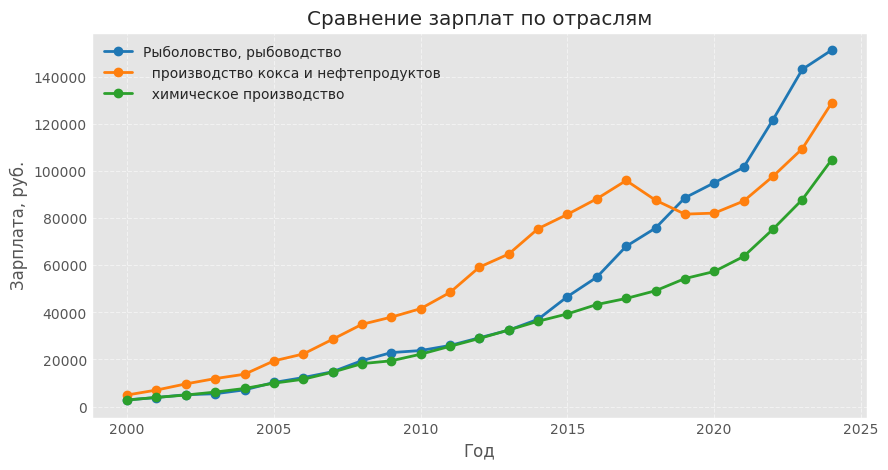

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('main.csv', sep=';', encoding='utf-8')
df = df.set_index('Год').T
df.index = pd.to_numeric(df.index)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, column in enumerate(df.columns):
    plt.figure(figsize=(8, 4))
    plt.plot(df.index, df[column], marker='o', color=colors[i], linewidth=2)
    
    plt.title(f'Динамика зарплаты: {column}')
    plt.xlabel('Год')
    plt.ylabel('Зарплата, руб.')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    last_value = df[column].iloc[-1]
    plt.text(df.index[-1], last_value, f'{last_value:.0f}', ha='left', va='center')

plt.figure(figsize=(10, 5))
for i, column in enumerate(df.columns):
    plt.plot(df.index, df[column], marker='o', color=colors[i], 
             linewidth=2, label=column)

plt.title('Сравнение зарплат по отраслям')
plt.xlabel('Год')
plt.ylabel('Зарплата, руб.')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

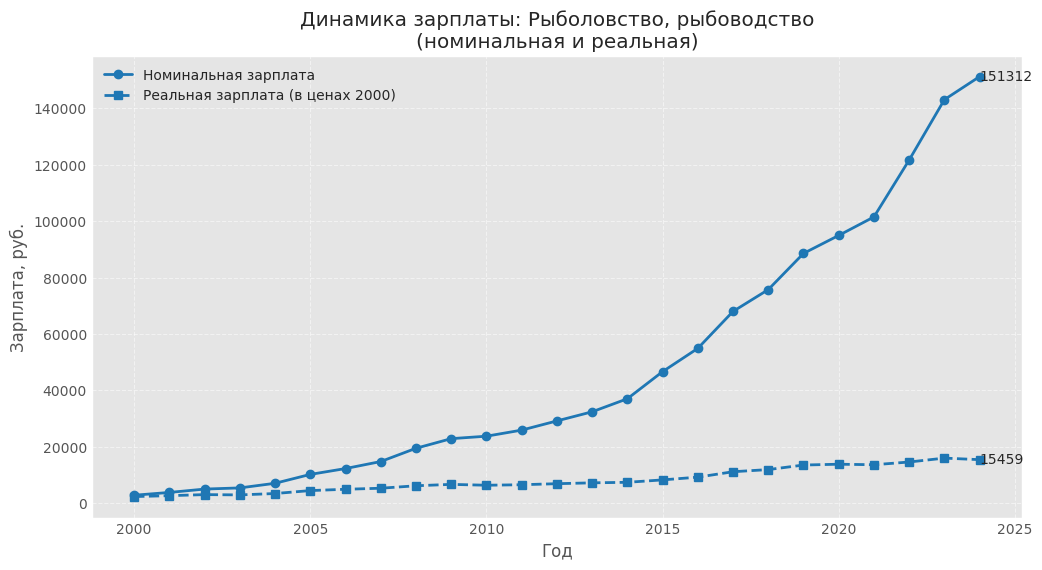

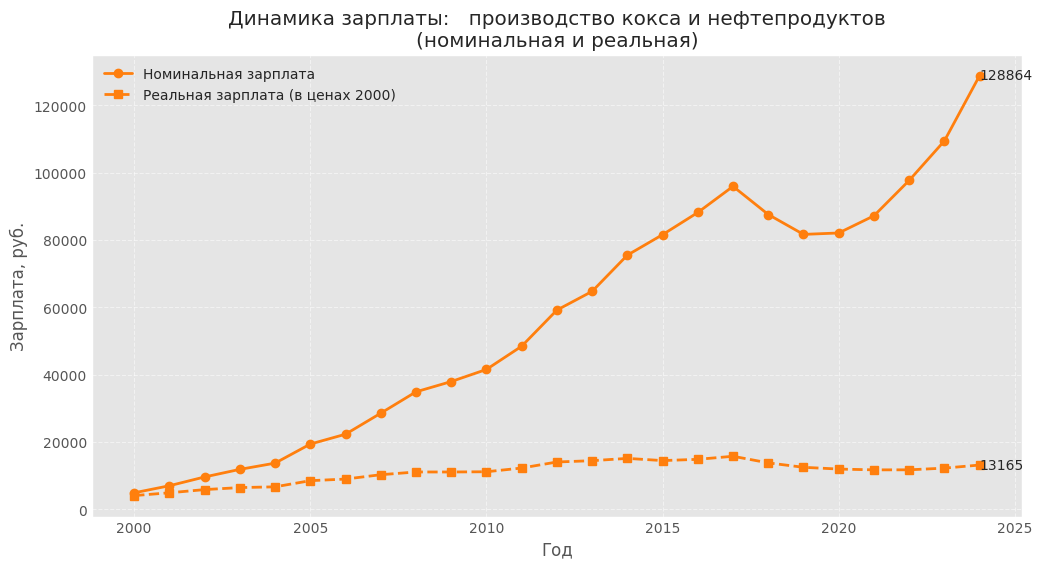

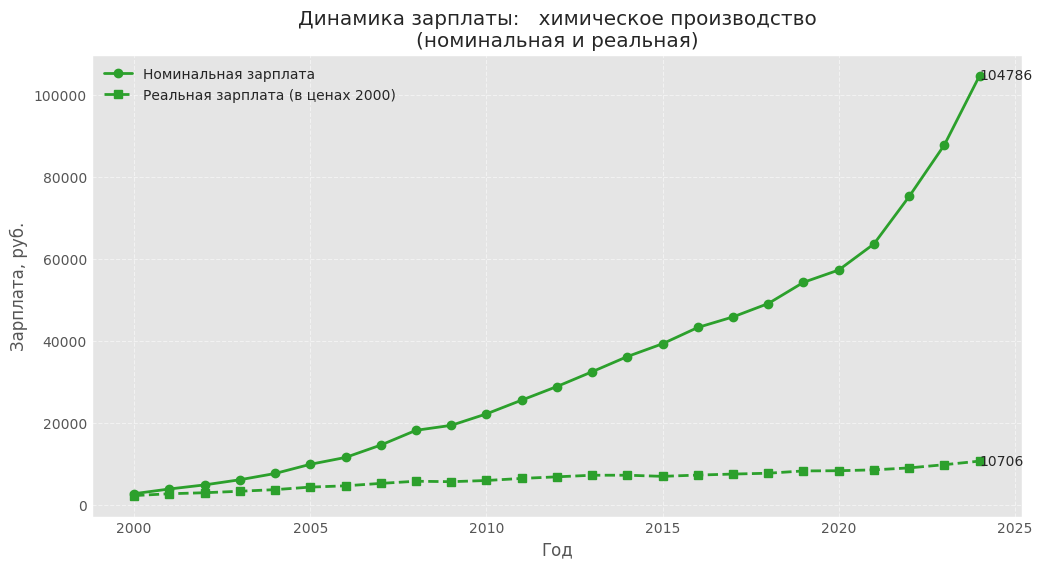

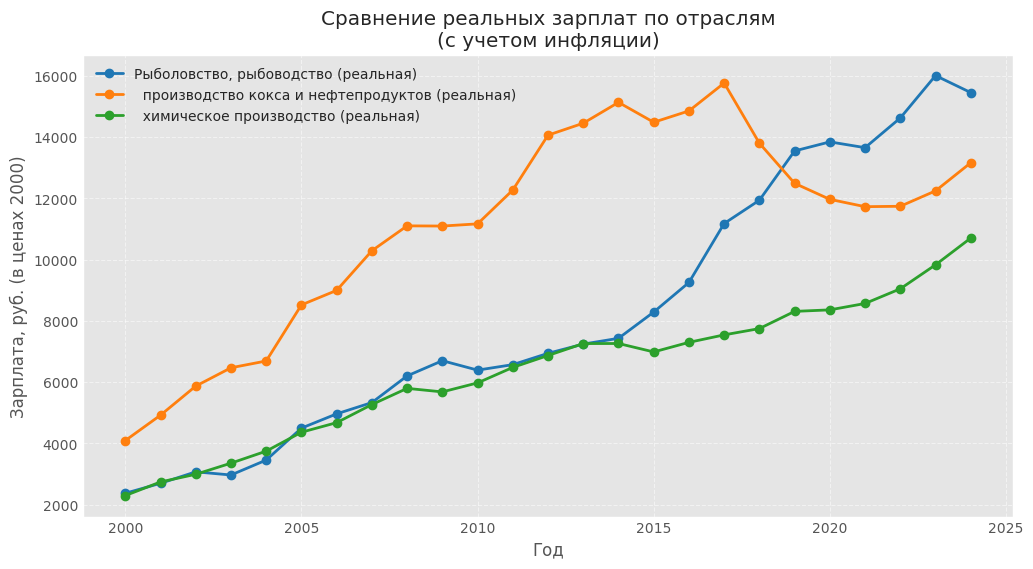

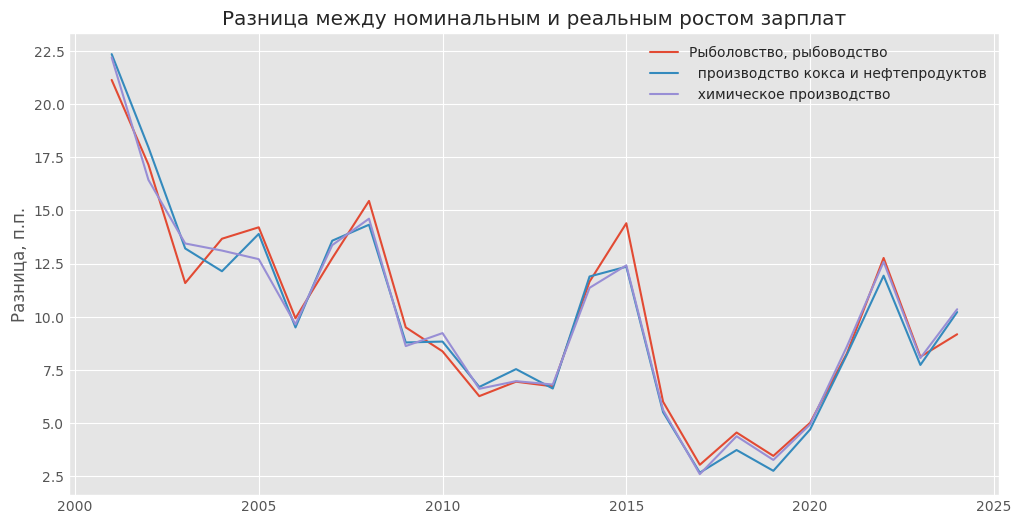

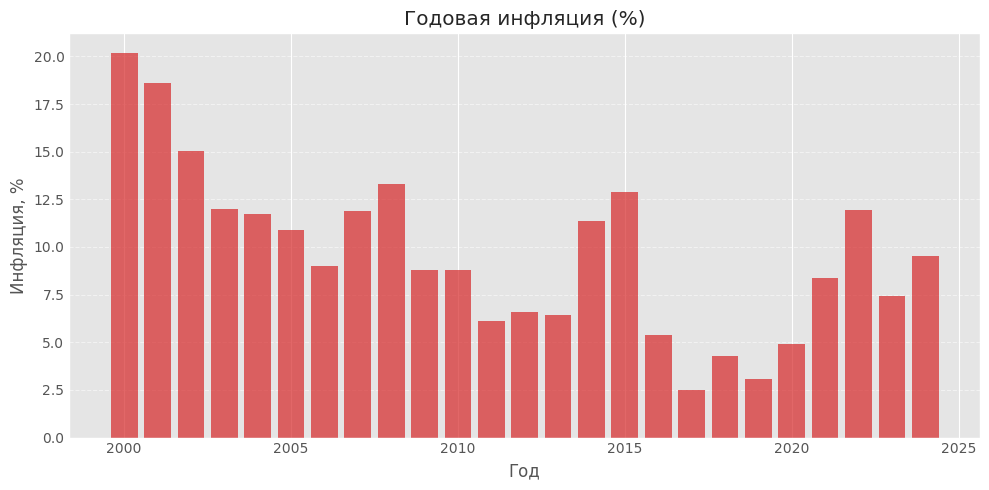


Реальные зарплаты с учетом инфляции:
      Рыболовство, рыбоводство    производство кокса и нефтепродуктов  \
2000                   2367.72                                4089.85   
2001                   2693.41                                4919.56   
2002                   3067.71                                5868.95   
2003                   2964.68                                6467.86   
2004                   3452.32                                6689.76   
2005                   4496.21                                8521.88   
2006                   4962.13                                8996.40   
2007                   5331.32                               10291.89   
2008                   6201.83                               11104.39   
2009                   6698.53                               11098.16   
2010                   6391.14                               11169.58   
2011                   6570.29                               12275.09   
2012         

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

salary_df = pd.read_csv('main.csv', sep=';', encoding='utf-8')
salary_df = salary_df.set_index('Год').T
salary_df.index = pd.to_numeric(salary_df.index)
inflation_df = pd.read_csv('inflation.csv', sep=';', encoding='utf-8')
inflation_df = inflation_df[['Год', 'Всего']] 

inflation_df['Всего'] = inflation_df['Всего'].str.replace(',', '.').astype(float)
inflation_df['Год'] = pd.to_numeric(inflation_df['Год'])
inflation_df = inflation_df.set_index('Год')

df = salary_df.join(inflation_df, how='inner')

def adjust_for_inflation(df, base_year=2000):
    adjusted_df = pd.DataFrame(index=df.index)
    inflation_factors = (1 + df['Всего']/100).cumprod()
    
    for column in salary_df.columns:
        adjusted_df[column] = df[column] / inflation_factors
    
    return adjusted_df

base_year = 2000
adjusted_salaries = adjust_for_inflation(df, base_year)

# Настройки графиков
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
plt.style.use('ggplot') 

for i, column in enumerate(salary_df.columns):
    plt.figure(figsize=(12, 6))
    
    plt.plot(salary_df.index, salary_df[column], 
             marker='o', color=colors[i], linewidth=2, 
             label='Номинальная зарплата')
    
    plt.plot(adjusted_salaries.index, adjusted_salaries[column], 
             marker='s', linestyle='--', color=colors[i], linewidth=2,
             label=f'Реальная зарплата (в ценах {base_year})')
    
    plt.title(f'Динамика зарплаты: {column}\n(номинальная и реальная)')
    plt.xlabel('Год')
    plt.ylabel('Зарплата, руб.')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    last_nominal = salary_df[column].iloc[-1]
    last_real = adjusted_salaries[column].iloc[-1]
    plt.text(salary_df.index[-1], last_nominal, f'{last_nominal:.0f}', ha='left', va='center')
    plt.text(adjusted_salaries.index[-1], last_real, f'{last_real:.0f}', ha='left', va='center')

plt.figure(figsize=(12, 6))
for i, column in enumerate(adjusted_salaries.columns):
    plt.plot(adjusted_salaries.index, adjusted_salaries[column], 
             marker='o', color=colors[i], linewidth=2, 
             label=f'{column} (реальная)')

plt.title('Сравнение реальных зарплат по отраслям\n(с учетом инфляции)')
plt.xlabel('Год')
plt.ylabel(f'Зарплата, руб. (в ценах {base_year})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Добавить после расчета adjusted_salaries
annual_real_growth = adjusted_salaries.pct_change() * 100

plt.figure(figsize=(12,6))
for col in salary_df.columns:
    diff = salary_df[col].pct_change()*100 - annual_real_growth[col]
    plt.plot(diff.index, diff, label=col)
plt.title("Разница между номинальным и реальным ростом зарплат")
plt.ylabel("Разница, п.п.")
plt.legend()

# 3. График инфляции
plt.figure(figsize=(10, 5))
plt.bar(inflation_df.index, inflation_df['Всего'], 
        color='#d62728', alpha=0.7)
plt.title('Годовая инфляция (%)')
plt.xlabel('Год')
plt.ylabel('Инфляция, %')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

print("\nРеальные зарплаты с учетом инфляции:")
print(adjusted_salaries.round(2))
print("\nАнализ изменений:")
for column in adjusted_salaries.columns:
    growth = (adjusted_salaries[column].iloc[-1] / adjusted_salaries[column].iloc[0] - 1) * 100
    print(f"{column}: реальная зарплата изменилась на {growth:.1f}% за период")